<a href="https://colab.research.google.com/github/adhikaryramen87/MachineLearning_Works/blob/main/The_Barcodeless_Produce_Assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extract the data

In [ ]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_f653c543a4f2398e13546e56666ae068"

In [ ]:
!pip install -q kaggle kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

print("Dataset downloaded to:", path)

100%|██████████| 1.98G/1.98G [00:21<00:00, 97.4MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8


In [ ]:
data_path = "/root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8"
os.listdir(data_path)

['validation', 'train', 'test']

In [ ]:
train_dir = os.path.join(data_path, "train")
val_dir = os.path.join(data_path, "validation")
test_dir = os.path.join(data_path, "test")

In [ ]:
def count_images(folder):
  for cls in os.listdir(folder):
    cls_path = os.path.join(folder, cls)
    print(f'{cls}: {len(os.listdir(cls_path))} images')

print('Train Set')
count_images(train_dir)

Train Set
chilli pepper: 87 images
apple: 68 images
capsicum: 89 images
banana: 75 images
paprika: 83 images
jalepeno: 88 images
sweetpotato: 69 images
beetroot: 88 images
carrot: 82 images
lemon: 82 images
kiwi: 88 images
pomegranate: 79 images
mango: 86 images
ginger: 68 images
peas: 100 images
turnip: 98 images
onion: 94 images
lettuce: 97 images
cauliflower: 79 images
soy beans: 97 images
eggplant: 84 images
tomato: 92 images
cabbage: 92 images
pear: 89 images
potato: 77 images
spinach: 97 images
raddish: 81 images
watermelon: 84 images
pineapple: 99 images
garlic: 92 images
grapes: 100 images
bell pepper: 90 images
corn: 87 images
orange: 69 images
cucumber: 94 images
sweetcorn: 91 images


In [ ]:
# !unzip /content/Fruits_and_Vegetables.zip

Archive:  /content/Fruits_and_Vegetables.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/Fruits_and_Vegetables.zip or
        /content/Fruits_and_Vegetables.zip.zip, and cannot find /content/Fruits_and_Vegetables.zip.ZIP, period.


Import all the required libraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report

Define the image parameters

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

Data Augmentation

In [ ]:
# augmentation + normalization => helps the model to improve the overall generalization
train_data_aug = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 30,
    horizontal_flip = True,
    vertical_flip = True,
    brightness_range = [0.8, 1.2]
)

# only normalization, no augmentation
val_data_aug = ImageDataGenerator(rescale=1./255)

Create Dataset Generators

In [ ]:
train_generator = train_data_aug.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)

val_generator = val_data_aug.flow_from_directory(
    val_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)

test_generator = val_data_aug.flow_from_directory(
    test_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False
)

Found 3115 images belonging to 36 classes.
Found 351 images belonging to 36 classes.
Found 359 images belonging to 36 classes.


Visualize the data samples

train_generator is not storing all the images in memory. It's a lazy loader (iterator)

So, instead of loading the entire data in one go, it loads -> process -> yield batch

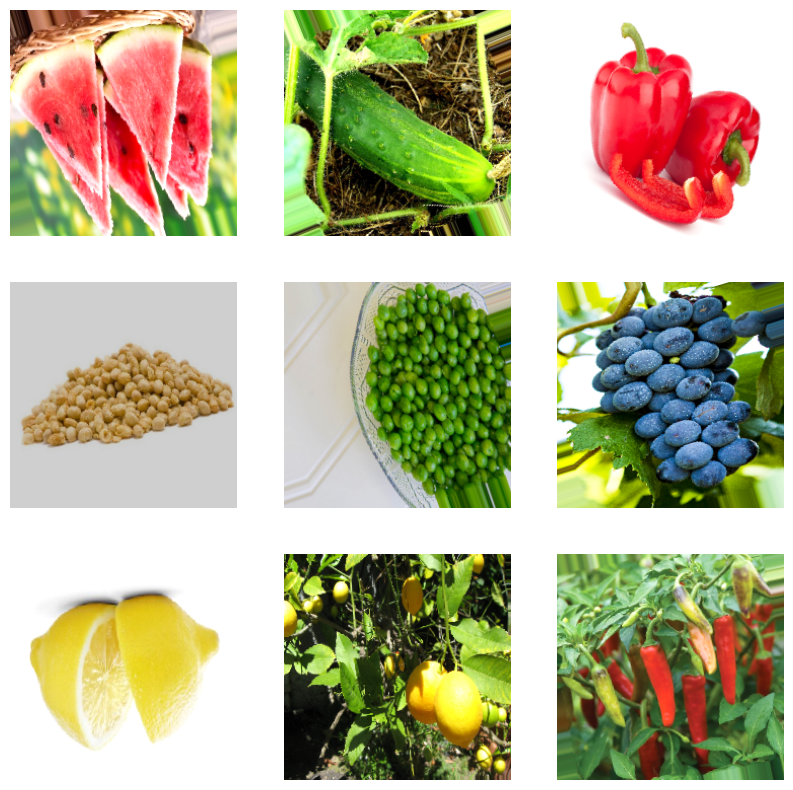

In [ ]:
image, labels = next(train_generator)
plt.figure(figsize=(10, 10))

for i in range(9):
  plt.subplot(3, 3, i+1)
  plt.imshow(image[i])
  plt.axis('off')

plt.show()

**Baseline CNN Model**

Architecture:

Conv -> ReLU -> Pool

Conv -> ReLU -> Pool

Conv -> ReLU -> Pool

Dense -> Softmax

CNN Model from scratch

In [ ]:
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation = 'relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3,3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3,3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile the model

In [ ]:
baseline_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

Model Training

In [ ]:
history_baseline = baseline_model.fit(train_generator, validation_data=val_generator, epochs = 10)

Epoch 1/10
 3/98 ━━━━━━━━━━━━━━━━━━━━ 35s 375ms/step - accuracy: 0.0191 - loss: 4.2277

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


98/98 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.0642 - loss: 3.4830 - val_accuracy: 0.1481 - val_loss: 3.0055
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.1143 - loss: 3.1144 - val_accuracy: 0.2393 - val_loss: 2.5495
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.1573 - loss: 2.8540 - val_accuracy: 0.2422 - val_loss: 2.4960
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.1827 - loss: 2.7305 - val_accuracy: 0.3305 - val_loss: 2.2291
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.2202 - loss: 2.6004 - val_accuracy: 0.4387 - val_loss: 2.0323
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.2372 - loss: 2.5130 - val_accuracy: 0.4103 - val_loss: 1.9612
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.2424 - loss: 2.4912 - val_accuracy: 0.3818 - val_loss: 1.9324
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.2684 - loss: 2.4330 - val_accuracy: 0.4558 - val_loss: 1.

Transfer Learning

In [ ]:
base_model = MobileNetV2(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)

for layer in base_model.layers:
  layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256,activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

predictions = Dense(train_generator.num_classes,activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history_transfer = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.3782 - loss: 2.3453 - val_accuracy: 0.8177 - val_loss: 0.7239
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.6485 - loss: 1.1894 - val_accuracy: 0.8604 - val_loss: 0.4817
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.7053 - loss: 0.9529 - val_accuracy: 0.8860 - val_loss: 0.3763
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.7393 - loss: 0.8200 - val_accuracy: 0.8974 - val_loss: 0.3574
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7547 - loss: 0.7479 - val_accuracy: 0.8917 - val_loss: 0.3051
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.7798 - loss: 0.6707 - val_accuracy: 0.9031 - val_loss: 0.2793
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.7961 - loss: 0.6212 - val_accuracy: 0.8946 - val_loss: 0.2910
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.8090 - loss: 0.5657 - val_accuracy: 0.9117 - v

Confusion Matrix

In [ ]:
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions,axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true,y_pred)

print(cm)

12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step
[[10  0  0 ...  0  0  0]
 [ 1  7  0 ...  0  0  0]
 [ 0  0 10 ...  0  0  0]
 ...
 [ 0  0  0 ... 10  0  0]
 [ 0  0  0 ...  0 10  0]
 [ 0  0  0 ...  0  0 10]]


GradCAM Explainability

In [ ]:
def get_gradcam_heatmap(img_array, model, last_conv_layer):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer).output, model.output]
    )

    # tensorflow records operations for automatic differentiation
    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model([img_array])
        class_channel = predictions[:, np.argmax(predictions[0])]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    # multiplication each feature map with its imporance weight and then summing up
    # weighted sum of feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    # remove any extra dimensions
    heatmap = tf.squeeze(heatmap)
    # remove any negative values and normalize the values between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

Visualization of the gradcam heatmap

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_15']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


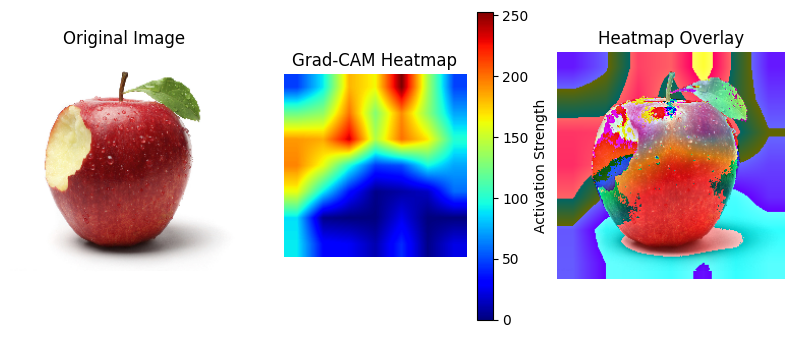

In [ ]:
last_conv_layer = "Conv_1"

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

img_path = test_generator.filepaths[0]

# Load image
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)

# Prepare input for model
input_array = np.expand_dims(img_array, axis=0) / 255.0

# Generate Grad-CAM heatmap
heatmap = get_gradcam_heatmap(input_array, model, last_conv_layer)

# Resize heatmap to match image size
heatmap = cv2.resize(heatmap, (224,224))

# Normalize heatmap
heatmap = np.uint8(255 * heatmap)

# Apply color map
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Overlay heatmap on original image
superimposed_img = heatmap_color * 0.4 + img_array

# Plot results
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img_array.astype("uint8"))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.colorbar(label="Activation Strength")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(superimposed_img.astype("uint8"))
plt.title("Heatmap Overlay")
plt.axis("off")

plt.show()